# INFO-6147-(01)-26W Deep Learning with Pytorch

## Project:

**Student Name:** Yun-Jiung Wang

**Student Number:** 1256222

**Date:** March 30th, 2026

**Description:**

## Setup Env

In [1]:
!pip install datasets
!pip install gradio

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from sklearn.metrics import confusion_matrix, f1_score
import seaborn as sns
from torch.utils.data import random_split
from tqdm import tqdm

## Device

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [24]:
EPOCHS=5
BATCH_SIZE = 128
LEARNING_RATE=0.001
DATA_PATH = './data'

##Load dataset (if run in local)

In [3]:
# from datasets import load_dataset

# dataset = load_dataset('ethz/food101')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00008.parquet:   0%|          | 0.00/490M [00:00<?, ?B/s]

data/train-00001-of-00008.parquet:   0%|          | 0.00/464M [00:00<?, ?B/s]

data/train-00002-of-00008.parquet:   0%|          | 0.00/472M [00:00<?, ?B/s]

...

data/validation-00000-of-00003.parquet:   0%|          | 0.00/423M [00:00<?, ?B/s]

data/validation-00001-of-00003.parquet:   0%|          | 0.00/413M [00:00<?, ?B/s]

data/validation-00002-of-00003.parquet:   0%|          | 0.00/426M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/75750 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/25250 [00:00<?, ? examples/s]

## Load Dataset (Colab)

In [27]:
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load dataset
train_dataset = datasets.Food101(root=DATA_PATH, split='train', download=True, transform=transform)
test_dataset = datasets.Food101(root=DATA_PATH, split='test', download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

num_classes = len(train_dataset.classes)
print(f"Load Food101 Successfully！Num of Classes: {num_classes}")

Load Food101 Successfully！Num of Classes: 101


## Build the model

In [32]:
# model = models.resnet50(pretrained=True)
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE,weight_decay=1e-4)

## Train

In [29]:
history={
    'train_loss': [], 'train_acc': [],
    'test_loss': [], 'test_acc': []
}

for epoch in range(EPOCHS):
    # --- train process ---
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    # training bar
    train_pbar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")

    for i, (images, labels) in train_pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        #calculate
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        # update process bar
        train_pbar.set_postfix({'Loss': f"{loss.item():.4f}", 'Acc': f"{100.*correct/total:.2f}%"})

    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_acc = 100. * correct / total

    # --- (Evaluate) ---
    model.eval()
    t_loss, t_correct, t_total = 0.0, 0, 0


    test_pbar = tqdm(test_loader, total=len(test_loader), desc=f"Epoch {epoch+1}/{EPOCHS} [Test]", leave=False)

    with torch.no_grad():
        for images, labels in test_pbar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            t_loss += loss.item()
            _, predicted = outputs.max(1)
            t_total += labels.size(0)
            t_correct += predicted.eq(labels).sum().item()

    epoch_test_loss = t_loss / len(test_loader)
    epoch_test_acc = 100. * t_correct / t_total

    # record to history
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['test_loss'].append(epoch_test_loss)
    history['test_acc'].append(epoch_test_acc)

    print(f"==> Epoch {epoch+1} ends | Train Acc: {epoch_train_acc:.2f}% | Test Acc: {epoch_test_acc:.2f}%")

Epoch 1/5 [Train]: 100%|██████████| 592/592 [03:37<00:00,  2.72it/s, Loss=1.6892, Acc=48.08%]
                                                                   

==> Epoch 1 ends | Train Acc: 48.08% | Test Acc: 53.07%


Epoch 2/5 [Train]: 100%|██████████| 592/592 [03:46<00:00,  2.61it/s, Loss=1.3039, Acc=65.03%]
                                                                   

==> Epoch 2 ends | Train Acc: 65.03% | Test Acc: 57.92%


Epoch 3/5 [Train]: 100%|██████████| 592/592 [03:46<00:00,  2.61it/s, Loss=0.8422, Acc=73.63%]
                                                                   

==> Epoch 3 ends | Train Acc: 73.63% | Test Acc: 66.12%


Epoch 4/5 [Train]: 100%|██████████| 592/592 [03:46<00:00,  2.61it/s, Loss=0.8497, Acc=80.45%]
                                                                   

==> Epoch 4 ends | Train Acc: 80.45% | Test Acc: 66.12%


Epoch 5/5 [Train]: 100%|██████████| 592/592 [03:46<00:00,  2.62it/s, Loss=0.5968, Acc=86.12%]
                                                                   

==> Epoch 5 ends | Train Acc: 86.12% | Test Acc: 64.38%


## Graphing Loss Curve and Accuarcy Curve

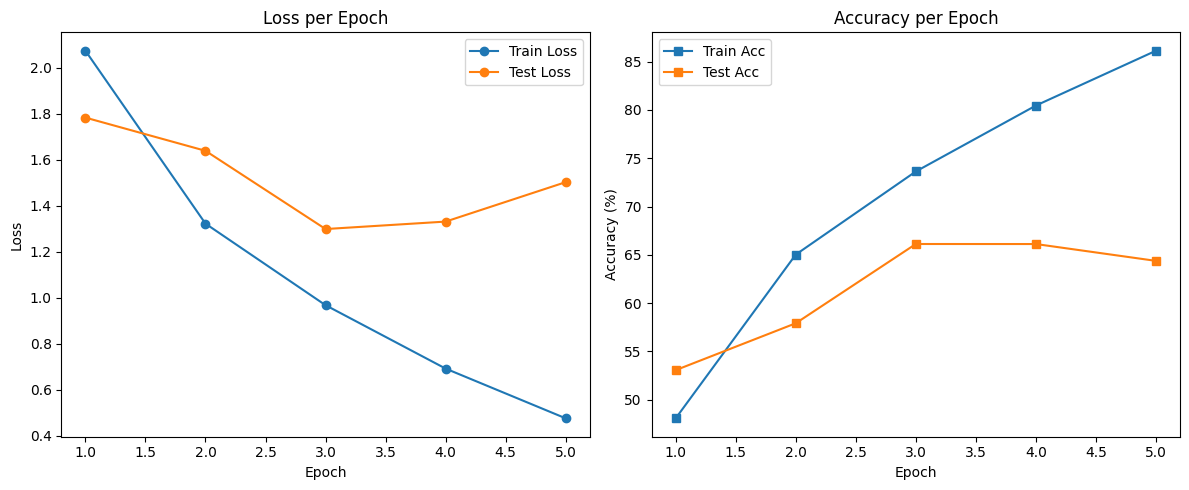

In [30]:
plt.figure(figsize=(12, 5))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS+1), history['train_loss'], label='Train Loss', marker='o')
plt.plot(range(1, EPOCHS+1), history['test_loss'], label='Test Loss', marker='o')
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS+1), history['train_acc'], label='Train Acc', marker='s')
plt.plot(range(1, EPOCHS+1), history['test_acc'], label='Test Acc', marker='s')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()